In [ ]:
# -*- coding: utf-8 -*-
#  Copyright 2026 United Kingdom Research and Innovation
#  Copyright 2026 The University of Manchester
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
# Authors:
# Adina W (UKRI-STFC)
# Julia P (UKRI-STFC)
# Laura Murgatroyd (UKRI-STFC)
# Evan Kiely (Warwick Manufacturing Group, University of Warwick)
# Hannah Robarts (UKRI-STFC)

# TescanDataReader Ibuprofen Demo

## CIL Version

This notebook was developed using CIL v26.0.0


In [2]:
import cil
cil.version.version

'26.0.0'


Tescan data is stored as tiff files. Data acquisition settings are stored in the Acquisiton Settings XRE.txt file

## Dataset
The dataset is a CT scan of an ibuprofen capsule collected by Evelien Zwanenburg and Jay Warnett at WMG on a Tescan Unitom XL. The dataset can be downloaded from https://zenodo.org/records/14993616. Specifically this notebook was created working with the '750 acq' data, the direct download link is: https://zenodo.org/records/15001770/files/Tescan%20Ibuprofen%20750%20acq.zip 

Update this filepath to where you have saved the dataset:

In [3]:
file_path = '/mnt/data/Work_Experience/Ibuprofen/Acquisition settings XRE.txt'


## Loading Geometry

In [4]:
from readers.TescanDataReader import TescanDataReader
from cil.utilities.display import show2D, show_geometry

/home/laura/miniconda3/envs/cil_demos_26/lib/python3.12/site-packages/cil/processors/CofR_image_sharpness.py:21: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  import scipy


Create a `TescanDataReader` object and give it the file_path

In [5]:
reader = TescanDataReader(file_path)

/mnt/data/Work_Experience/Ibuprofen/Acquisition settings XRE.txt
1200


First we just get the geometry and visualise and print it to check it looks right

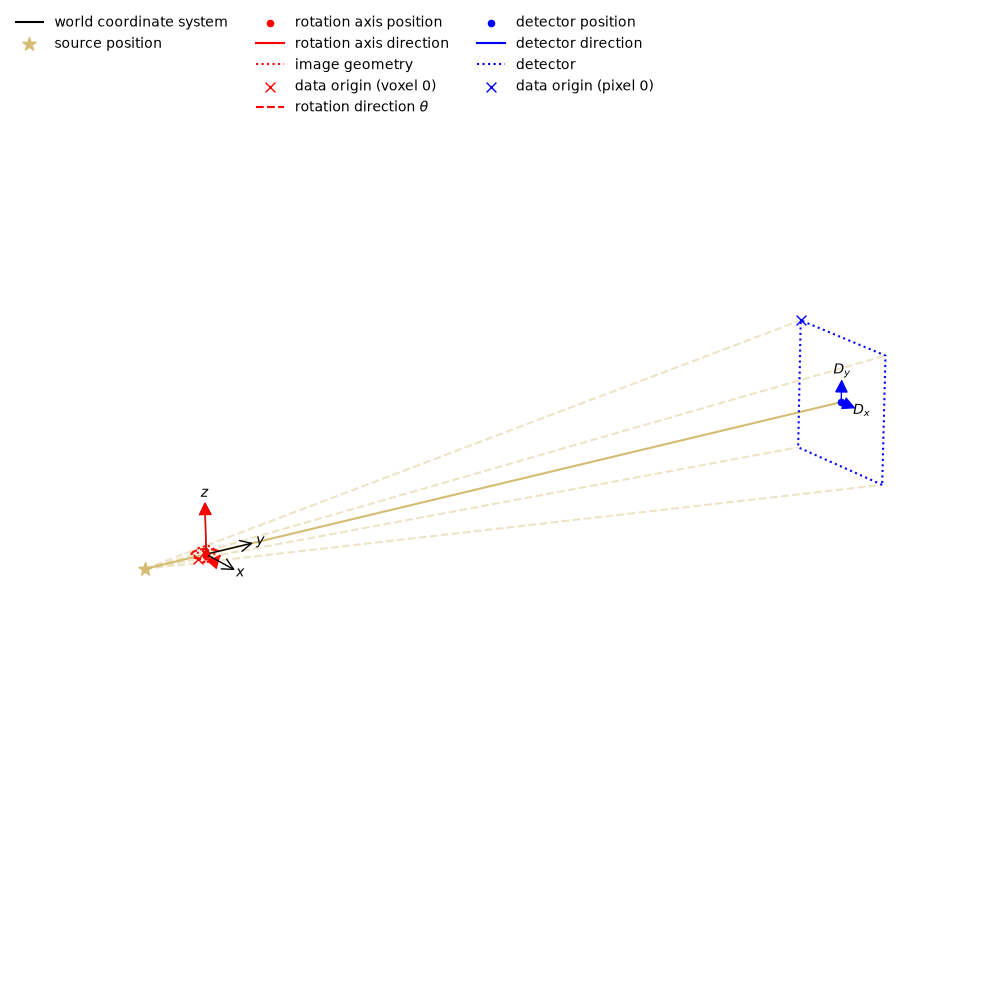

3D Cone-beam tomography
System configuration:
	Source position: [   0.      , -109.999985,    0.      ]
	Rotation axis position: [0., 0., 0.]
	Rotation axis direction: [0., 0., 1.]
	Detector position: [   0.      , 1239.999771,    0.      ]
	Detector direction x: [1., 0., 0.]
	Detector direction y: [0., 0., 1.]
Panel configuration:
	Number of pixels: [750 750]
	Pixel size: [0.3 0.3]
	Pixel origin: top-left
Channel configuration:
	Number of channels: 1
Acquisition description:
	Number of positions: 1200
	Angles 0-9 in degrees: [0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7]
	Angles 1190-1199 in degrees: [357. , 357.3, 357.6, 357.9, 358.2, 358.5, 358.8, 359.1, 359.4, 359.7]
	Full angular array can be accessed with acquisition_data.geometry.angles
Distances in units: units distance


In [6]:
acq_geom = reader.get_geometry()
show_geometry(acq_geom)
print(acq_geom)

## Loading Projections, Flat and Dark Fields

Next we load the dataset and use `show2D` to look at a single projection

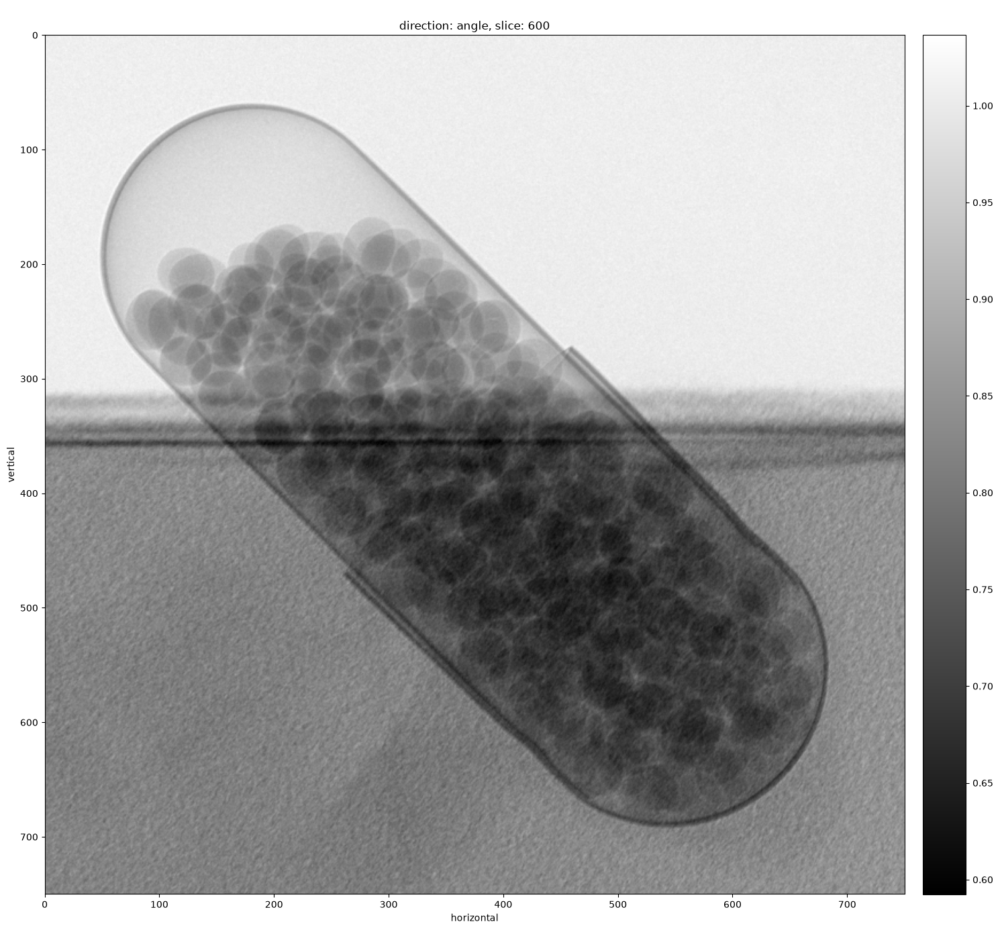

In [7]:
data = reader.read()

show2D(data, origin='upper-left')

The loaded data is normalised by default (we can turn this off by specifing `TescanDataReader(filename,normalise=False)`). If we want to check the dark and flat files we use the `load_darkfield()` and `load_flatfield()` methods.

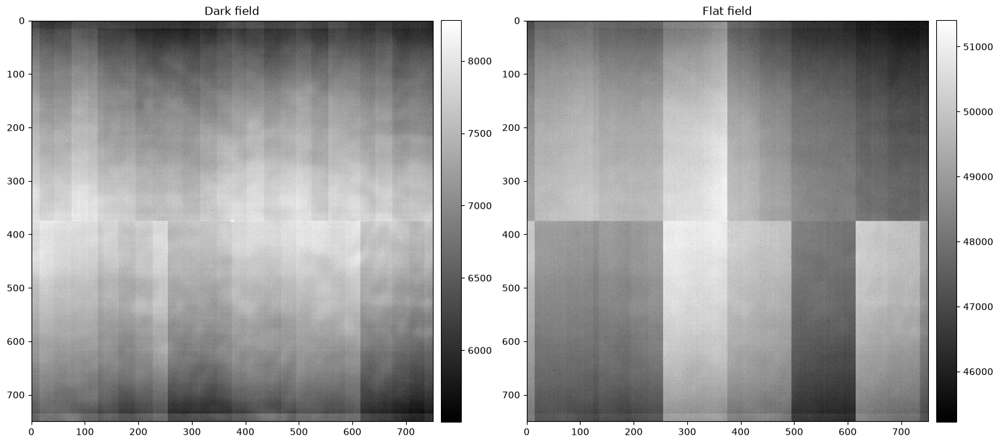

In [8]:
dark_field = reader.load_darkfield()
flat_field = reader.load_flatfield()

show2D([dark_field, flat_field], ['Dark field', 'Flat field'], origin='upper-left')

# Pre-processing and Reconstruction

In [9]:
from cil.processors import TransmissionAbsorptionConverter, CentreOfRotationCorrector
from cil.recon import FDK
import numpy as np

Now we run some pre-processing steps on the data.

First we use the Beer-Lambert law to convert from transmission to absorption. 

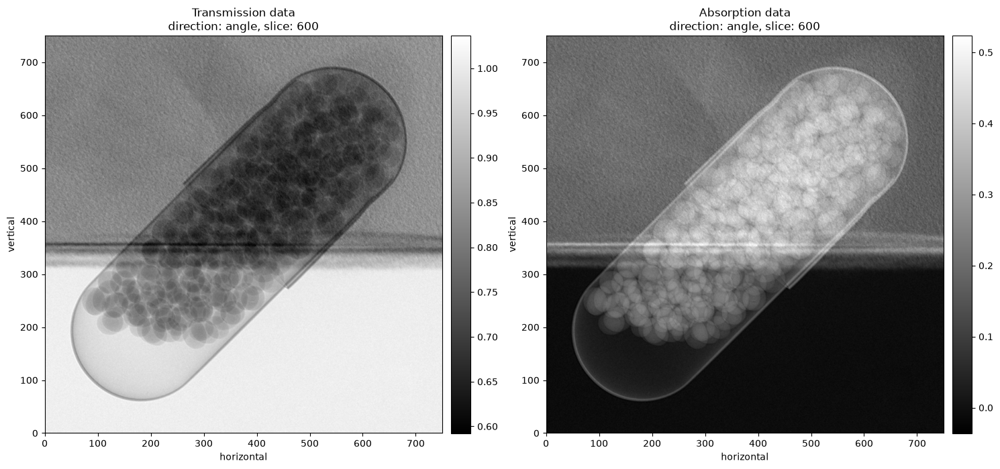

In [10]:
data_abs = TransmissionAbsorptionConverter()(data)
show2D([data, data_abs], ['Transmission data', 'Absorption data'])

We can use the fix_range parameter in show2D to change the displayed contrast:

In [11]:
print(np.min(data_abs.array), np.max(data_abs.array))

-0.046906315 0.6933091


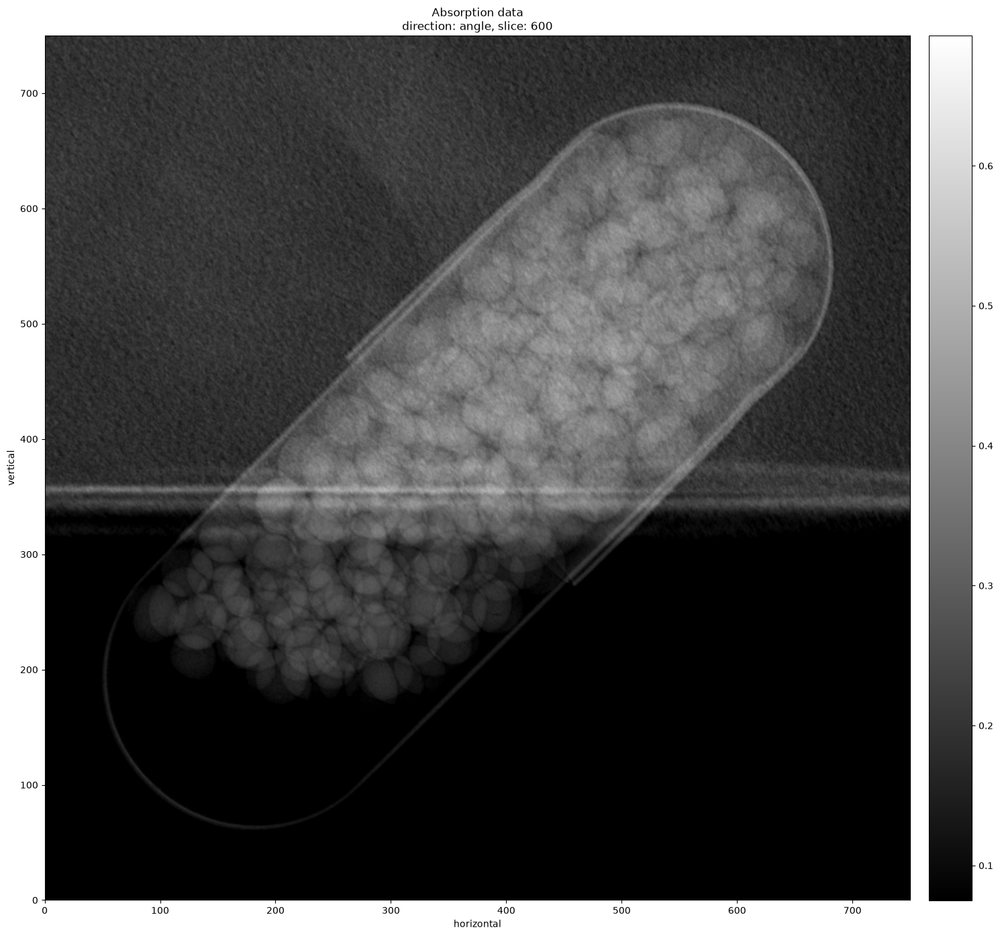

In [12]:
show2D(data_abs, 'Absorption data', fix_range=(0.075, 0.6933091))

Run a reconstruction using CIL FDK

FDK recon

Input Data:
	angle: 1200
	vertical: 750
	horizontal: 750

Reconstruction Volume:
	vertical: 750
	horizontal_y: 750
	horizontal_x: 750

Reconstruction Options:
	Backend: tigre
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 11
	Filter_inplace: False



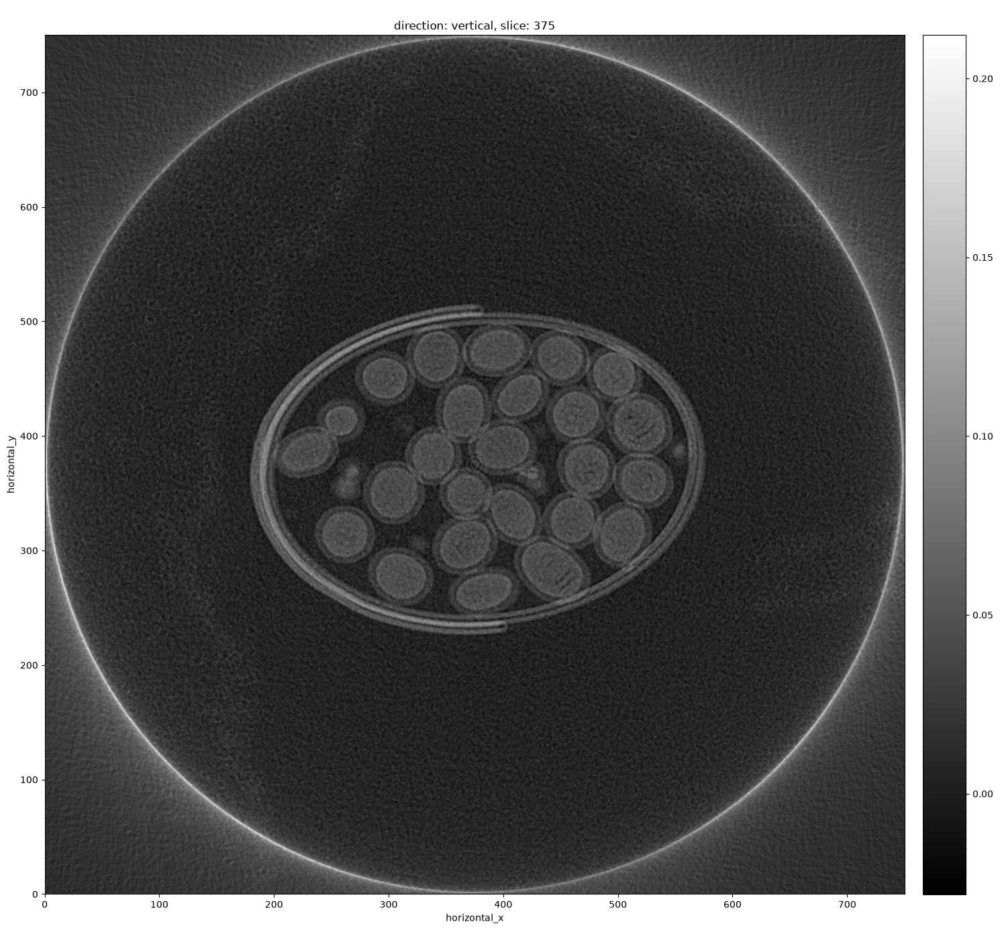

In [13]:
recon = FDK(data_abs).run()
show2D(recon)

Next we try to optimise the centre of rotation position

In [14]:
print(f"Centre of rotation before = {data_abs.geometry.get_centre_of_rotation(distance_units='pixels')}")
data_abs = CentreOfRotationCorrector.image_sharpness(backend='tigre', search_range=100, tolerance=0.1)(data_abs)
print(f"Centre of rotation after = {data_abs.geometry.get_centre_of_rotation(distance_units='pixels')}")

Centre of rotation before = {'offset': (np.float64(0.0), 'pixels'), 'angle': (0.0, 'radian')}


Centre of rotation after = {'offset': (np.float64(-3.0161601677738847), 'pixels'), 'angle': (0.0, 'radian')}


Check if this has an impact on the reconstruction

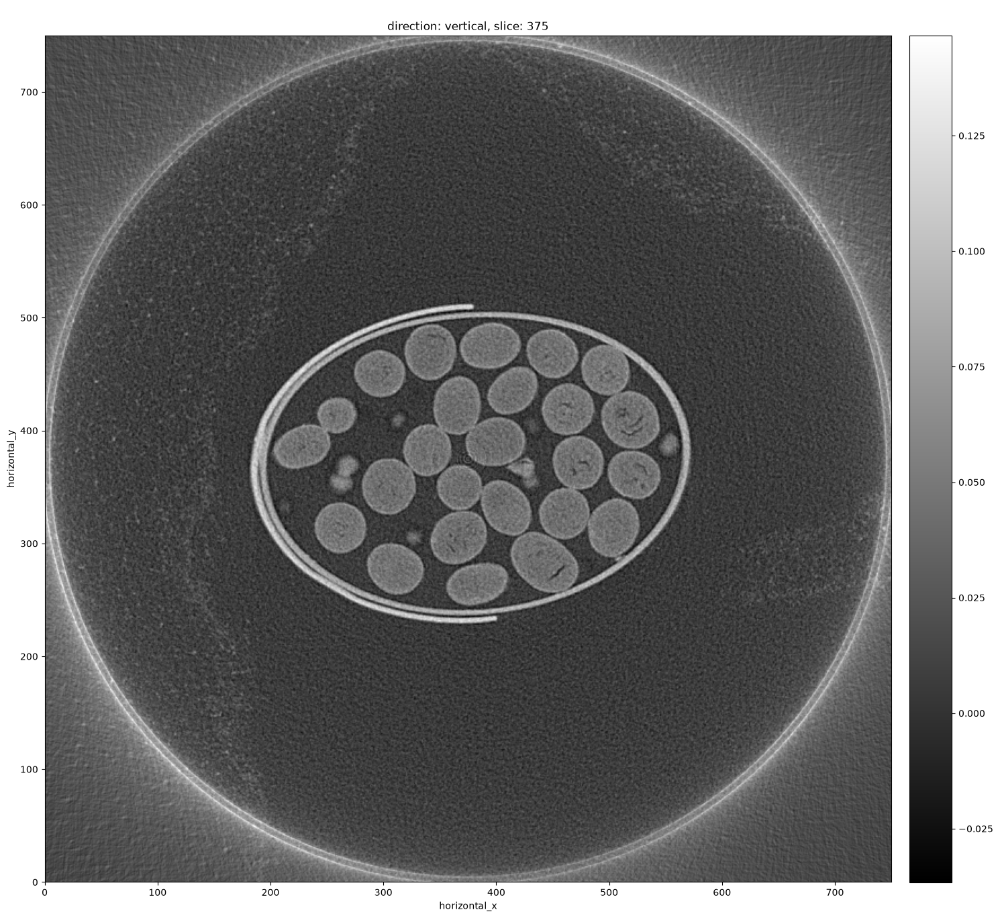

In [15]:
recon_abs = FDK(data_abs).run(verbose=False)
show2D(recon_abs)

For a reconstructed slice of interest, we could crop to a smaller square region showing the sample:

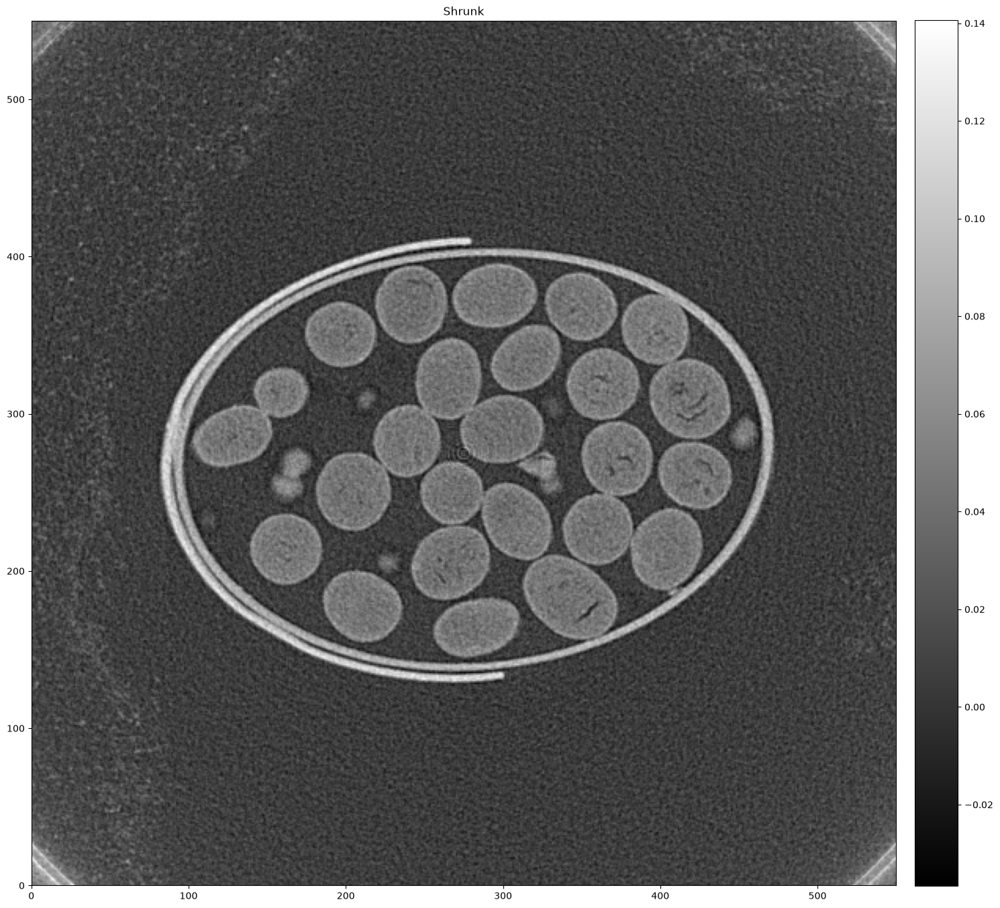

In [16]:
show2D([ recon_abs.array[375,100:650,100:650]], ['Shrunk'])

We can reduce the size of the Image Geometry as we know the sample does not take up the full area of the default Image Geometry:

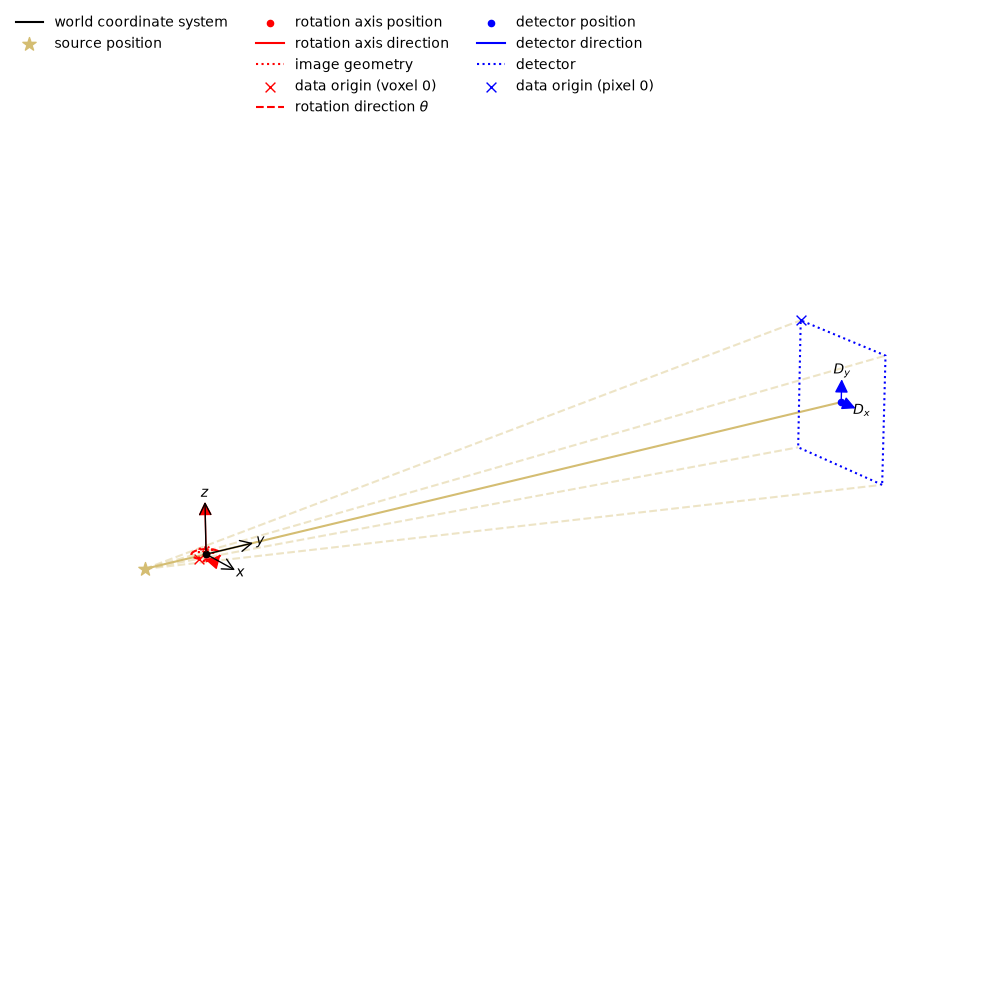

FDK recon

Input Data:
	angle: 1200
	vertical: 750
	horizontal: 750

Reconstruction Volume:
	vertical: 650
	horizontal_y: 650
	horizontal_x: 650

Reconstruction Options:
	Backend: tigre
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 11
	Filter_inplace: False



In [17]:
# get the default image geometry
cropped_ig = data_abs.geometry.get_ImageGeometry()

# modify the number of voxels in X, Y and Z 
cropped_ig.voxel_num_x = 650
cropped_ig.voxel_num_y = 650
cropped_ig.voxel_num_z = 650

# show the the geometry
show_geometry(data_abs.geometry, cropped_ig)

# create an FDK algorithm with the new geometry
fdk =  FDK(data_abs, cropped_ig)

#run the algorithm to get the reconstruction
recon = fdk.run()

By using islicer we can see that the full sample is still within the reconstructed volume:

In [18]:
from cil.utilities.jupyter import islicer
islicer(recon)

# Reader arguments

Try reading a subset of the data using the `roi` argument.

First we reduce the horizontal and vertical range

/mnt/data/Work_Experience/Ibuprofen/Acquisition settings XRE.txt
1200


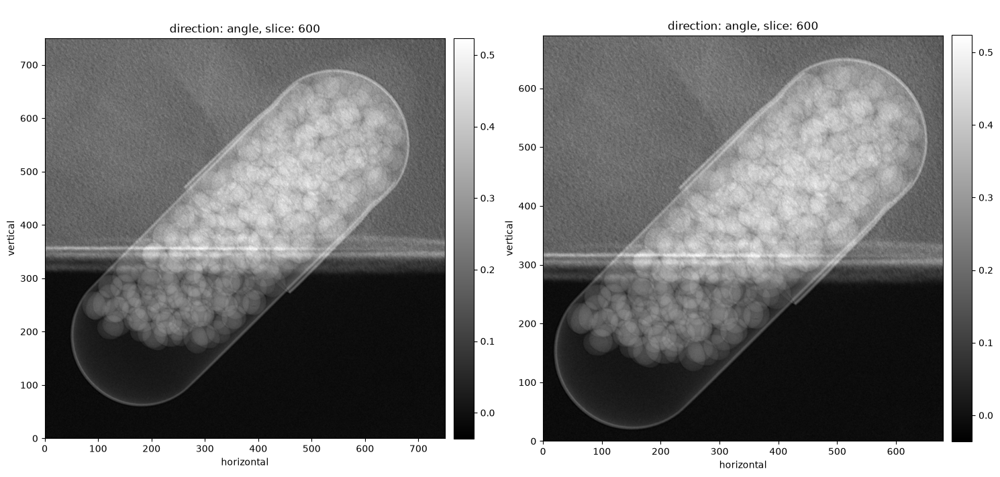

In [19]:
data_cropped = TescanDataReader(file_path, roi={'horizontal':(30,710,1), 'vertical':(40,730,1)}).read()
data_cropped = TransmissionAbsorptionConverter()(data_cropped)
show2D([data_abs, data_cropped])

Next we try binning the data using `roi={'horizontal':(0,-1,3), 'vertical':(0,-1,3)}` to specify the full range in vertical and horizontal but binned 3x.

/mnt/data/Work_Experience/Ibuprofen/Acquisition settings XRE.txt
1200


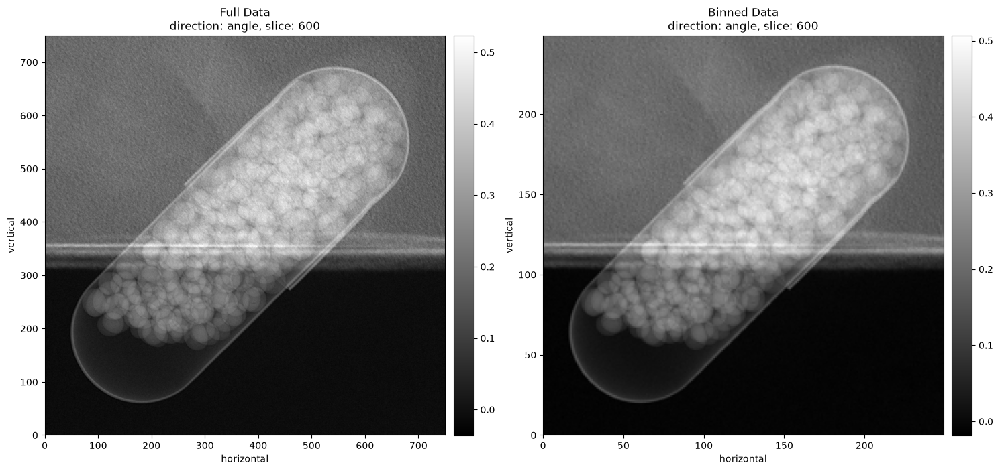

In [20]:
data_binned = TescanDataReader(file_path, roi={'horizontal':(0,-1,3), 'vertical':(0,-1,3)},
                               normalise=True).read()
data_binned = TransmissionAbsorptionConverter()(data_binned)
show2D([data_abs, data_binned], title=["Full Data", "Binned Data"]);